In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 0 — Verify Paths

In [1]:
import os, glob

PREP_DIR = '/kaggle/input/datasets/majorproject777/flood-preprocessed'
TEMP_DIR = '/kaggle/input/datasets/majorproject777/preprocessed-temporal/preprocessed_temporal'

TRAIN_SPATIAL_DIR  = f'{PREP_DIR}/train'
VAL_SPATIAL_DIR    = f'{PREP_DIR}/val'
TRAIN_TEMPORAL_DIR = f'{TEMP_DIR}/train'
VAL_TEMPORAL_DIR   = f'{TEMP_DIR}/val'
NORM_STATS_PATH    = f'{PREP_DIR}/norm_stats.json'

checks = {
    'Train spatial dir' : TRAIN_SPATIAL_DIR,
    'Val spatial dir'   : VAL_SPATIAL_DIR,
    'Train temporal dir': TRAIN_TEMPORAL_DIR,
    'Val temporal dir'  : VAL_TEMPORAL_DIR,
    'norm_stats.json'   : NORM_STATS_PATH,
}
all_ok = True
for name, path in checks.items():
    if os.path.isdir(path):
        n = len(glob.glob(f'{path}/*.npy'))
        print(f'  {"✅" if n>0 else "❌"} {name:25s}: {n} files')
        if n == 0: all_ok = False
    elif os.path.isfile(path):
        print(f'  ✅ {name:25s}: exists')
    else:
        print(f'  ❌ {name:25s}: NOT FOUND')
        all_ok = False
print()
print('All paths verified ✅' if all_ok else 'Fix paths ❌')

  ✅ Train spatial dir        : 4128 files
  ✅ Val spatial dir          : 336 files
  ✅ Train temporal dir       : 2064 files
  ✅ Val temporal dir         : 168 files
  ✅ norm_stats.json          : exists

All paths verified ✅


# 1 — Imports & Config

In [2]:
import os, json, glob, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

BATCH_SIZE   = 4
NUM_WORKERS  = 2
PIN_MEMORY   = True
LR           = 1e-4
MAX_EPOCHS   = 100
PATIENCE     = 10
GRAD_CLIP    = 1.0
RANDOM_SEED  = 42

SPATIAL_CHANNELS  = 14
TEMPORAL_CHANNELS = 2
N_TIMESTEPS       = 15
N_TEMPORAL_FEATS  = 5   # 3-day sum, 7-day sum, 15-day sum, ERA5 mean, ERA5 trend
BASE_FEATURES     = 64
MLP_HIDDEN        = 128

# HAND channel index in spatial tensor
# Channel order: VV(0),VH(1),B2(2),B3(3),B4(4),B8(5),B11(6),B12(7),
#                Elev(8),Slope(9),TWI(10),HAND(11),NDWI(12),NDVI(13)
HAND_CHANNEL = 11

CKPT_DIR = '/kaggle/working/unet_temporal_mlp'
os.makedirs(CKPT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print(f'Device         : {DEVICE}')
print(f'GPU            : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')
print(f'Temporal feats : {N_TEMPORAL_FEATS} scalars per chip')
print(f'HAND channel   : {HAND_CHANNEL}')

Device         : cuda
GPU            : Tesla T4
Temporal feats : 5 scalars per chip
HAND channel   : 11


# 2 — Dataset

Key difference: temporal `.npy` is loaded but immediately converted to 5 physically-interpretable scalar features instead of being passed as a full tensor.

In [3]:
def extract_temporal_features(temporal):
    """
    Convert (15, 2, 512, 512) normalized temporal tensor
    to 5 physically-interpretable scalar features.

    Note: temporal is already normalized (z-score).
    We work in normalized space — features are still physically meaningful
    in relative terms (higher = more rain than average).

    Returns: (5,) float32 array
        [0] CHIRPS 3-day sum  — last 3 days (days 12-14)
        [1] CHIRPS 7-day sum  — last 7 days (days 8-14)
        [2] CHIRPS 15-day sum — all 15 days (days 0-14)
        [3] ERA5 mean         — mean soil moisture over 15 days
        [4] ERA5 trend        — slope of soil moisture (positive=wetting)
    """
    chirps = temporal[:, 0, :, :].mean(axis=(-2, -1))  # (15,) spatial mean per day
    era5   = temporal[:, 1, :, :].mean(axis=(-2, -1))  # (15,)

    # CHIRPS accumulation windows
    chirps_3d  = chirps[-3:].sum()    # last 3 days
    chirps_7d  = chirps[-7:].sum()    # last 7 days
    chirps_15d = chirps.sum()          # all 15 days

    # ERA5 statistics
    era5_mean  = era5.mean()

    # ERA5 trend — linear regression slope over 15 days
    # Positive = soil getting wetter, Negative = drying
    days       = np.arange(15, dtype=np.float32)
    days_norm  = days - days.mean()
    era5_norm  = era5 - era5.mean()
    era5_trend = (days_norm * era5_norm).sum() / (days_norm ** 2).sum()

    return np.array([
        chirps_3d,
        chirps_7d,
        chirps_15d,
        era5_mean,
        era5_trend,
    ], dtype=np.float32)


class FloodDataset(Dataset):
    """
    Returns:
        spatial       : (14, 512, 512) float32
        temporal_feats: (5,) float32 — scalar features, NOT full temporal tensor
        label         : (512, 512) int16
    """
    def __init__(self, spatial_dir, temporal_dir, augment=False):
        self.spatial_dir  = spatial_dir
        self.temporal_dir = temporal_dir
        self.augment      = augment

        self.chip_ids = sorted([
            os.path.basename(f).replace('_spatial.npy', '')
            for f in glob.glob(f'{spatial_dir}/*_spatial.npy')
        ])

        missing = [
            c for c in self.chip_ids
            if not os.path.exists(f'{temporal_dir}/{c}_temporal.npy')
        ]
        if missing:
            raise FileNotFoundError(f'{len(missing)} temporal files missing. First 3: {missing[:3]}')

        print(f'Dataset: {len(self.chip_ids)} chips | augment={augment}')

    def __len__(self):
        return len(self.chip_ids)

    def __getitem__(self, idx):
        chip_id  = self.chip_ids[idx]
        spatial  = np.load(f'{self.spatial_dir}/{chip_id}_spatial.npy')   # (14, 512, 512)
        temporal = np.load(f'{self.temporal_dir}/{chip_id}_temporal.npy') # (15, 2, 512, 512)
        label    = np.load(f'{self.spatial_dir}/{chip_id}_label.npy')     # (512, 512)

        # Extract 5 scalar temporal features
        temp_feats = extract_temporal_features(temporal)  # (5,)

        if self.augment:
            spatial, label = self._augment(spatial, label)
            # Note: temp_feats are scalars — augmentation doesn't apply

        return (
            torch.from_numpy(spatial.astype(np.float32)),
            torch.from_numpy(temp_feats),
            torch.from_numpy(label.astype(np.int16)),
        )

    def _augment(self, spatial, label):
        if random.random() > 0.5:
            spatial = spatial[:, :, ::-1].copy()
            label   = label[:, ::-1].copy()
        if random.random() > 0.5:
            spatial = spatial[:, ::-1, :].copy()
            label   = label[::-1, :].copy()
        k = random.randint(0, 3)
        if k > 0:
            spatial = np.rot90(spatial, k, axes=(1, 2)).copy()
            label   = np.rot90(label,   k, axes=(0, 1)).copy()
        return spatial, label


train_dataset = FloodDataset(TRAIN_SPATIAL_DIR, TRAIN_TEMPORAL_DIR, augment=True)
val_dataset   = FloodDataset(VAL_SPATIAL_DIR,   VAL_TEMPORAL_DIR,   augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')

# Check feature values
sp, tf, lb = next(iter(train_loader))
print(f'\nBatch spatial shape       : {sp.shape}')
print(f'Batch temporal feats shape: {tf.shape}  (expected (4, 5))')
print(f'Batch label shape         : {lb.shape}')
print(f'\nTemporal feature stats (batch mean):')
feat_names = ['CHIRPS 3d sum', 'CHIRPS 7d sum', 'CHIRPS 15d sum', 'ERA5 mean', 'ERA5 trend']
for i, name in enumerate(feat_names):
    print(f'  {name:20s}: mean={tf[:, i].mean():.4f}  std={tf[:, i].std():.4f}')

Dataset: 2064 chips | augment=True
Dataset: 168 chips | augment=False
Train batches: 516
Val batches  : 42

Batch spatial shape       : torch.Size([4, 14, 512, 512])
Batch temporal feats shape: torch.Size([4, 5])  (expected (4, 5))
Batch label shape         : torch.Size([4, 512, 512])

Temporal feature stats (batch mean):
  CHIRPS 3d sum       : mean=1.1490  std=2.0948
  CHIRPS 7d sum       : mean=1.2845  std=2.7226
  CHIRPS 15d sum      : mean=1.4117  std=3.9474
  ERA5 mean           : mean=0.6228  std=0.0256
  ERA5 trend          : mean=0.0048  std=0.0044


# 3 — Model Architecture

**Terrain-Conditioned Temporal MLP**

The 5 scalar temporal features are processed by an MLP and broadcast to the
bottleneck spatial resolution (32×32). Crucially, this broadcast is **modulated
by the HAND channel** from the spatial encoder — pixels closer to drainage
(low HAND) get stronger temporal influence than hilltop pixels (high HAND).

This terrain conditioning is physically motivated:
- Low HAND + high antecedent rainfall → very flood susceptible
- High HAND + high antecedent rainfall → much less susceptible
- The HAND channel already exists in the spatial tensor (channel 11)

In [4]:
# ── U-Net Blocks ──────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        return self.conv(torch.cat([self.up(x), skip], dim=1))


# ── Terrain-Conditioned Temporal MLP ──────────────────────────────────────
class TerrainConditionedTemporalMLP(nn.Module):
    """
    Processes 5 scalar temporal features through an MLP,
    then conditions the output on local terrain (HAND).

    Step 1 — MLP: (B, 5) → (B, out_channels)
    Step 2 — Broadcast: (B, out_channels) → (B, out_channels, 32, 32)
    Step 3 — HAND conditioning: multiply by sigmoid(HAND_at_32x32)
             Low HAND (near drainage) → sigmoid close to 1 → strong temporal signal
             High HAND (hilltop)      → sigmoid close to 0 → weak temporal signal

    The HAND conditioning is a learned gating mechanism — the network learns
    how much to trust temporal context at each spatial location based on terrain.
    """
    def __init__(self, n_features, hidden_size, out_channels, bottleneck_size=32):
        super().__init__()
        self.bottleneck_size = bottleneck_size
        self.out_channels    = out_channels

        # MLP: 5 scalars → out_channels
        self.mlp = nn.Sequential(
            nn.Linear(n_features, hidden_size),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, out_channels),
        )

        # HAND gating: learned transform of HAND map → gating weights [0, 1]
        # Takes downsampled HAND (1 channel at 32×32) → out_channels gates
        self.hand_gate = nn.Sequential(
            nn.Conv2d(1, out_channels, 1, bias=True),  # 1×1 conv
            nn.Sigmoid(),  # gate values in [0, 1]
        )

        # Pool HAND to bottleneck resolution
        self.hand_pool = nn.AdaptiveAvgPool2d((bottleneck_size, bottleneck_size))

    def forward(self, temp_feats, spatial):
        """
        temp_feats : (B, 5) scalar temporal features
        spatial    : (B, 14, 512, 512) spatial tensor — used to extract HAND
        """
        # ── MLP branch ────────────────────────────────────────────────────
        t = self.mlp(temp_feats)                              # (B, out_channels)
        t = t.unsqueeze(-1).unsqueeze(-1)                     # (B, out_channels, 1, 1)
        t = t.expand(-1, -1, self.bottleneck_size,
                              self.bottleneck_size)            # (B, out_channels, 32, 32)

        # ── HAND conditioning ─────────────────────────────────────────────
        hand = spatial[:, HAND_CHANNEL:HAND_CHANNEL+1, :, :]  # (B, 1, 512, 512)
        hand = self.hand_pool(hand)                            # (B, 1, 32, 32)
        gate = self.hand_gate(hand)                            # (B, out_channels, 32, 32)

        # Gate the temporal features by terrain
        # Low HAND → gate near 1 → temporal signal passes through
        # High HAND → gate near 0 → temporal signal suppressed
        return t * gate                                        # (B, out_channels, 32, 32)


# ── Full Model ────────────────────────────────────────────────────────────
class UNetTemporalMLP(nn.Module):
    """
    U-Net + Terrain-Conditioned Temporal MLP (Variant 5).

    Inputs:
        spatial    : (B, 14, 512, 512)
        temp_feats : (B, 5) scalar temporal features
    Output:
        logits     : (B, 1, 512, 512)
    """
    def __init__(self,
                 spatial_channels = 14,
                 n_temporal_feats = 5,
                 mlp_hidden       = 128,
                 base_features    = 64):
        super().__init__()
        f = base_features

        # Spatial encoder
        self.enc1    = ConvBlock(spatial_channels, f)
        self.enc2    = Down(f,   f*2)
        self.enc3    = Down(f*2, f*4)
        self.enc4    = Down(f*4, f*8)
        self.down_bn = nn.MaxPool2d(2)

        # Terrain-conditioned temporal MLP
        self.temporal_mlp = TerrainConditionedTemporalMLP(
            n_features      = n_temporal_feats,
            hidden_size     = mlp_hidden,
            out_channels    = f*8,        # match spatial bottleneck
            bottleneck_size = 32,
        )

        # Fusion + bottleneck
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(f*8 + f*8, f*8, 1, bias=False),
            nn.BatchNorm2d(f*8),
            nn.ReLU(inplace=True),
        )
        self.bottleneck = ConvBlock(f*8, f*16)

        # Decoder
        self.dec4 = Up(f*16, f*8,  f*8)
        self.dec3 = Up(f*8,  f*4,  f*4)
        self.dec2 = Up(f*4,  f*2,  f*2)
        self.dec1 = Up(f*2,  f,    f)
        self.head = nn.Conv2d(f, 1, 1)

    def forward(self, spatial, temp_feats):
        # Spatial encoder
        e1   = self.enc1(spatial)
        e2   = self.enc2(e1)
        e3   = self.enc3(e2)
        e4   = self.enc4(e3)
        s_bn = self.down_bn(e4)                           # (B, f*8, 32, 32)

        # Terrain-conditioned temporal features
        t_feat = self.temporal_mlp(temp_feats, spatial)   # (B, f*8, 32, 32)

        # Fusion
        fused = torch.cat([s_bn, t_feat], dim=1)
        fused = self.fusion_conv(fused)
        bn    = self.bottleneck(fused)

        # Decoder
        d4 = self.dec4(bn, e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)
        return self.head(d1)


# Instantiate
model = UNetTemporalMLP(
    spatial_channels = SPATIAL_CHANNELS,
    n_temporal_feats = N_TEMPORAL_FEATS,
    mlp_hidden       = MLP_HIDDEN,
    base_features    = BASE_FEATURES,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params/1e6:.1f}M')
print(f'(vs ConvLSTM ~32-35M — MLP branch adds very few parameters)')

# Forward pass check
with torch.no_grad():
    dummy_sp = torch.randn(1, SPATIAL_CHANNELS, 512, 512).to(DEVICE)
    dummy_tf = torch.randn(1, N_TEMPORAL_FEATS).to(DEVICE)
    dummy_out = model(dummy_sp, dummy_tf)
    print(f'Input spatial      : {dummy_sp.shape}')
    print(f'Input temp feats   : {dummy_tf.shape}')
    print(f'Output             : {dummy_out.shape}  (expected (1, 1, 512, 512))')
del dummy_sp, dummy_tf, dummy_out
torch.cuda.empty_cache()

Parameters: 32.0M
(vs ConvLSTM ~32-35M — MLP branch adds very few parameters)
Input spatial      : torch.Size([1, 14, 512, 512])
Input temp feats   : torch.Size([1, 5])
Output             : torch.Size([1, 1, 512, 512])  (expected (1, 1, 512, 512))


# 4 — Loss & Metrics

In [5]:
def dice_loss(pred, target, mask, eps=1e-6):
    pred   = torch.sigmoid(pred).squeeze(1)
    target = target.float()
    pred   = pred * mask
    target = target * mask
    intersection = (pred * target).sum(dim=(1, 2))
    union        = pred.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
    return 1 - ((2 * intersection + eps) / (union + eps)).mean()

def bce_loss(pred, target, mask):
    return F.binary_cross_entropy_with_logits(
        pred.squeeze(1)[mask], target.float()[mask]
    )

def combined_loss(pred, target):
    mask        = (target != -1)
    label_clean = target.clone()
    label_clean[~mask] = 0
    return 0.5 * dice_loss(pred, label_clean, mask) + \
           0.5 * bce_loss(pred,  label_clean, mask)

def compute_metrics(pred_logits, target):
    mask     = (target != -1)
    pred_bin = (torch.sigmoid(pred_logits).squeeze(1) > 0.5).long()
    p = pred_bin[mask].cpu()
    t = target[mask].cpu()
    TP = ((p==1) & (t==1)).sum().float()
    FP = ((p==1) & (t==0)).sum().float()
    FN = ((p==0) & (t==1)).sum().float()
    eps = 1e-6
    return {
        'iou'      : (TP / (TP + FP + FN + eps)).item(),
        'f1'       : (2*TP / (2*TP + FP + FN + eps)).item(),
        'precision': (TP / (TP + FP + eps)).item(),
        'recall'   : (TP / (TP + FN + eps)).item(),
    }

print('Loss and metrics defined ✅')

Loss and metrics defined ✅


# 5 — Training Loop

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

BEST_MODEL_PATH = f'{CKPT_DIR}/best_model.pth'
LAST_MODEL_PATH = f'{CKPT_DIR}/last_model.pth'
LOG_PATH        = f'{CKPT_DIR}/training_log.json'

start_epoch    = 0
best_val_iou   = 0.0
patience_count = 0
training_log   = []

if os.path.exists(LAST_MODEL_PATH):
    print('Resuming from checkpoint...')
    ckpt = torch.load(LAST_MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch    = ckpt['epoch'] + 1
    best_val_iou   = ckpt['best_val_iou']
    patience_count = ckpt['patience_count']
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH) as f:
            training_log = json.load(f)
    print(f'Resumed from epoch {start_epoch}, best IoU: {best_val_iou:.4f}')
else:
    print('Starting fresh training.')


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss  = 0
    all_metrics = {'iou': 0, 'f1': 0, 'precision': 0, 'recall': 0}
    n_batches   = 0
    desc = 'Train' if training else 'Val'
    ctx  = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for spatial, temp_feats, label in pbar:
            spatial    = spatial.to(DEVICE,    non_blocking=True)
            temp_feats = temp_feats.to(DEVICE, non_blocking=True)
            label      = label.to(DEVICE,      non_blocking=True)

            if (label != -1).sum() == 0:
                continue

            pred = model(spatial, temp_feats)
            loss = combined_loss(pred, label)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            total_loss += loss.item()
            metrics     = compute_metrics(pred, label)
            for k in all_metrics:
                all_metrics[k] += metrics[k]
            n_batches += 1
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'iou': f'{metrics["iou"]:.4f}'})

    avg = {k: v / n_batches for k, v in all_metrics.items()}
    avg['loss'] = total_loss / n_batches
    return avg


print(f'Starting from epoch {start_epoch} to {MAX_EPOCHS}')
print(f'Early stopping patience: {PATIENCE}')
print('-' * 90)

for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()
    train_metrics = run_epoch(train_loader, training=True)
    val_metrics   = run_epoch(val_loader,   training=False)
    scheduler.step(val_metrics['loss'])
    elapsed = time.time() - t0

    epoch_log = {
        'epoch': epoch,
        'train': {k: round(v, 4) for k, v in train_metrics.items()},
        'val'  : {k: round(v, 4) for k, v in val_metrics.items()},
        'lr'   : optimizer.param_groups[0]['lr'],
        'time_s': round(elapsed, 1),
    }
    training_log.append(epoch_log)

    print(
        f'Ep {epoch:>3}/{MAX_EPOCHS} | '
        f'Train loss={train_metrics["loss"]:.4f} IoU={train_metrics["iou"]:.4f} | '
        f'Val loss={val_metrics["loss"]:.4f} IoU={val_metrics["iou"]:.4f} '
        f'F1={val_metrics["f1"]:.4f} | '
        f'LR={optimizer.param_groups[0]["lr"]:.1e} | {elapsed:.0f}s'
    )

    torch.save({
        'epoch': epoch, 'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_iou': best_val_iou, 'patience_count': patience_count,
    }, LAST_MODEL_PATH)

    if val_metrics['iou'] > best_val_iou:
        best_val_iou   = val_metrics['iou']
        patience_count = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ✅ New best val IoU: {best_val_iou:.4f}')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE})')

    with open(LOG_PATH, 'w') as f:
        json.dump(training_log, f, indent=2)

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print(f'\nTraining complete. Best val IoU: {best_val_iou:.4f}')
with open(f'{CKPT_DIR}/final_metrics.json', 'w') as f:
    json.dump({'best_val_iou': best_val_iou, 'epochs_trained': epoch + 1}, f, indent=2)

Starting fresh training.
Starting from epoch 0 to 100
Early stopping patience: 10
------------------------------------------------------------------------------------------


Ep   0/100 | Train loss=0.4875 IoU=0.5141 | Val loss=0.3725 IoU=0.6596 F1=0.7684 | LR=1.0e-04 | 667s
  ✅ New best val IoU: 0.6596


Ep   1/100 | Train loss=0.3747 IoU=0.5790 | Val loss=0.3271 IoU=0.6042 F1=0.7164 | LR=1.0e-04 | 673s
  No improvement (1/10)


Ep   2/100 | Train loss=0.3174 IoU=0.6123 | Val loss=0.2781 IoU=0.6866 F1=0.7940 | LR=1.0e-04 | 671s
  ✅ New best val IoU: 0.6866


Ep   3/100 | Train loss=0.2874 IoU=0.6231 | Val loss=0.2416 IoU=0.7060 F1=0.8072 | LR=1.0e-04 | 673s
  ✅ New best val IoU: 0.7060


...

Ep  33/100 | Train loss=0.1861 IoU=0.7144 | Val loss=0.2399 IoU=0.7125 F1=0.8126 | LR=1.3e-05 | 676s
  No improvement (6/10)


Ep  34/100 | Train loss=0.1827 IoU=0.7126 | Val loss=0.2429 IoU=0.7131 F1=0.8113 | LR=1.3e-05 | 674s
  No improvement (7/10)


Ep  35/100 | Train loss=0.1818 IoU=0.7204 | Val loss=0.2384 IoU=0.7178 F1=0.8158 | LR=1.3e-05 | 674s
  No improvement (8/10)


Ep  36/100 | Train loss=0.1826 IoU=0.7159 | Val loss=0.2439 IoU=0.7105 F1=0.8091 | LR=1.3e-05 | 677s
  No improvement (9/10)


Ep  37/100 | Train loss=0.1800 IoU=0.7173 | Val loss=0.2529 IoU=0.7004 F1=0.8023 | LR=1.3e-05 | 676s
  No improvement (10/10)

Early stopping at epoch 37.

Training complete. Best val IoU: 0.7367


# 6 — Plot Training Curves

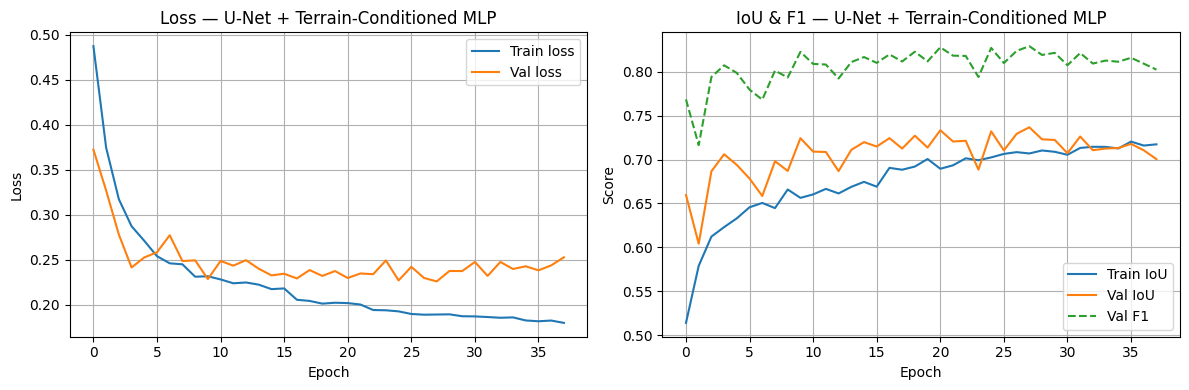

In [7]:
import matplotlib.pyplot as plt

with open(LOG_PATH) as f:
    log = json.load(f)

epochs     = [e['epoch'] for e in log]
train_loss = [e['train']['loss'] for e in log]
val_loss   = [e['val']['loss']   for e in log]
train_iou  = [e['train']['iou']  for e in log]
val_iou    = [e['val']['iou']    for e in log]
val_f1     = [e['val']['f1']     for e in log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, train_loss, label='Train loss')
ax1.plot(epochs, val_loss,   label='Val loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss — U-Net + Terrain-Conditioned MLP')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs, train_iou, label='Train IoU')
ax2.plot(epochs, val_iou,   label='Val IoU')
ax2.plot(epochs, val_f1,    label='Val F1', linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('IoU & F1 — U-Net + Terrain-Conditioned MLP')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 7 — Final Evaluation & Ablation Table

In [8]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
val_metrics = run_epoch(val_loader, training=False)

print('=== Final Val Metrics — U-Net + Terrain-Conditioned Temporal MLP ===')
print(f'  IoU       : {val_metrics["iou"]:.4f}')
print(f'  F1 / Dice : {val_metrics["f1"]:.4f}')
print(f'  Precision : {val_metrics["precision"]:.4f}')
print(f'  Recall    : {val_metrics["recall"]:.4f}')
print(f'  Loss      : {val_metrics["loss"]:.4f}')

print('\n=== Full Ablation Table ===')
print(f'{"Variant":45s}  {"IoU":>7}  {"F1":>7}')
print('-' * 63)
print(f'{"1 — U-Net spatial only":45s}  {0.7360:>7.4f}  {"TBD":>7}')
print(f'{"2 — U-Net + ConvLSTM (hidden=128, 1L)":45s}  {0.7315:>7.4f}  {0.8254:>7.4f}')
print(f'{"3 — U-Net + LSTM":45s}  {"TBD":>7}  {"TBD":>7}')
print(f'{"4 — U-Net + ConvLSTM V2 (hidden=256, 2L, attn)":45s}  {"TBD":>7}  {"TBD":>7}')
print(f'{"5 — U-Net + Terrain-Conditioned MLP":45s}  {val_metrics["iou"]:>7.4f}  {val_metrics["f1"]:>7.4f}')

with open(f'{CKPT_DIR}/final_metrics.json', 'w') as f:
    json.dump(val_metrics, f, indent=2)

=== Final Val Metrics — U-Net + Terrain-Conditioned Temporal MLP ===
  IoU       : 0.7367
  F1 / Dice : 0.8290
  Precision : 0.8963
  Recall    : 0.7927
  Loss      : 0.2261

=== Full Ablation Table ===
Variant                                            IoU       F1
---------------------------------------------------------------
1 — U-Net spatial only                          0.7360      TBD
2 — U-Net + ConvLSTM (hidden=128, 1L)           0.7315   0.8254
3 — U-Net + LSTM                                   TBD      TBD
4 — U-Net + ConvLSTM V2 (hidden=256, 2L, attn)      TBD      TBD
5 — U-Net + Terrain-Conditioned MLP             0.7367   0.8290


# 8 — Save to Kaggle

In [9]:
USERNAME = 'majorproject777'
meta = {
    'title'   : 'flood-temporal-mlp-model',
    'id'      : f'{USERNAME}/flood-temporal-mlp-model',
    'licenses': [{'name': 'CC0-1.0'}]
}
with open(f'{CKPT_DIR}/dataset-metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

!kaggle datasets create -p {CKPT_DIR} --dir-mode zip
print('Model uploaded to Kaggle ✅')

Starting upload for file final_metrics.json
100%|████████████████████████████████████████████| 155/155 [00:00<00:00, 438B/s]
Upload successful: final_metrics.json (155B)
Starting upload for file training_curves.png
100%|█████████████████████████████████████████| 117k/117k [00:00<00:00, 339kB/s]
Upload successful: training_curves.png (117KB)
Starting upload for file training_log.json
100%|██████████████████████████████████████| 12.3k/12.3k [00:00<00:00, 36.4kB/s]
Upload successful: training_log.json (12KB)
Starting upload for file last_model.pth
100%|████████████████████████████████████████| 366M/366M [00:05<00:00, 74.1MB/s]
Upload successful: last_model.pth (366MB)
Starting upload for file best_model.pth
100%|████████████████████████████████████████| 122M/122M [00:01<00:00, 86.4MB/s]
Upload successful: best_model.pth (122MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/majorproject777/flood-temporal-mlp-model
Model uploaded to Kaggle ✅